# Imports, config, TMX loading, cleaning, splits, basic EDA

j:\FINAL PROJECT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
Number of CUDA devices: 1
Device 0: NVIDIA GeForce RTX 5070 Laptop GPU


Filter: 100%|██████████| 10499/10499 [00:01<00:00, 7297.25 examples/s]

Final split sizes: EN→ES train 9982 / valid 500  |  EN→PT train 9978 / valid 500
 EN→ES random pairs:

=== SAMPLE 1824 ===
SRC: Official information regarding the structural and technical state of housing is contradictory.
TGT: Los datos oficiales sobre el estado estructural y técnico de la vivienda son contradictorios.

=== SAMPLE 409 ===
SRC: These categories are certainly not mutually exclusive, since they assume complementary perspectives or focuses to understand the concept of quality.
TGT: Ciertamente, estas categorías no son excluyentes entre sí, por cuanto suponen perspectivas o enfoques complementarios para entender lo que es la calidad.

=== SAMPLE 4506 ===
SRC: Teams designing checklists need to understand the different types e.g. challenge-response vs. read-do since different work flows will be supported by different styles of checklist.
TGT: Los equipos encargados de diseñar las listas de verificación deben comprender los distintos tipos por ejemplo, preguntar-responder vs

,idx,EN (src),XX (tgt)
0,0,His title emphasizes how inexplicable it was t...,Con este título enfatiza cómo en forma inexpli...
1,1,Shear wave velocities also vary from 60 to 300...,Así mismo las velocidades de onda cortante var...
2,2,All patients who underwent this procedure duri...,Se eligió como población de estudio a todos lo...
3,3,Foreigners were 5.4%.,"Había 5,4% de extranjeros."
4,4,"In such a manner, it is possible to study rado...",De esta manera se puede estudiar la presencia ...
5,5,This focus was present both in orientations pr...,Este enfoque existía tanto en las orientacione...
6,6,Although bilateral use of continuous 0.2% ropi...,Aunque se ha reportado administración continua...
7,7,The majority of PPIs are metabolized in the li...,La mayoría de los IBPs son metabolizados en el...
8,8,"Within this field, the components of perceptio...","Dentro de este campo, el componente de la perc..."
9,9,This review aims to describe the major recent ...,Esta revisión tiene por objeto describir los p...



 EN→ES length ratios (train):


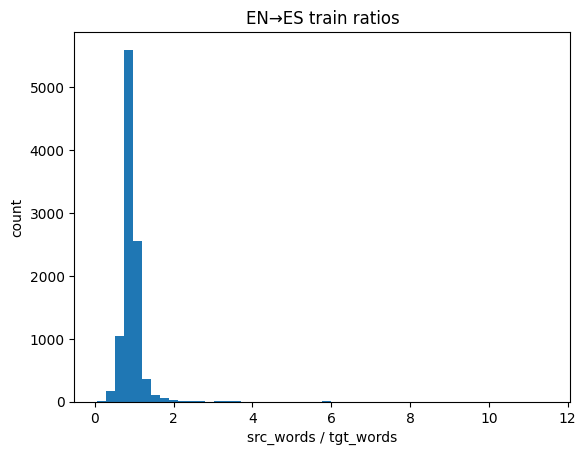

In [1]:
# CELL 1: imports, config, TMX loading, cleaning, splits, EDA

from pathlib import Path
import io, gzip, unicodedata
import os, sys, platform, random
import numpy as np
import regex as re
from xml.etree import ElementTree as ET
import langid
import torch
from datasets import Dataset
import evaluate
import inspect
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer,
)
import pandas as pd
import matplotlib.pyplot as plt

# Run knobs 
SEED = 42
PROJECT_DIR = "./nllb_bilingual_en_es_pt"
ROOT = Path(r"J:\FINAL PROJECT")  # path to root directory
TMX_ES = ROOT / "data" / "en-es.tmx"
TMX_PT = ROOT / "data" / "en-pt.tmx"

# dataset sizes
MAX_SAMPLES = 10000 # max per pair (train pool)
EVAL_SAMPLES = 500   # max per pair (eval pool)

# tokenization / model
MAX_SRC_LEN = 128
MAX_TGT_LEN = 128

# training
BATCH = 8
GRAD_ACCUM = 1
MAX_STEPS = 500
LR = 3e-5

# language codes for NLLB
NLLB_CKPT = "facebook/nllb-200-distilled-600M"
SRC_LANG = "eng_Latn"
ES_LANG = "spa_Latn"
PT_LANG = "por_Latn"

# fast-eval presets
FAST_MAX_NEW = 96
FAST_MIN_NEW = 2
FAST_BEAMS = 1
FAST_BATCH = 128

# Repro & device
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
use_bf16 = torch.cuda.is_available() and getattr(torch.cuda, "is_bf16_supported", lambda: False)()
use_fp16 = torch.cuda.is_available() and not use_bf16
os.makedirs(PROJECT_DIR, exist_ok=True)

print("CUDA available:", torch.cuda.is_available())
print("Number of CUDA devices:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"Device {i}:", torch.cuda.get_device_name(i))

#  LoRA helper 
from peft import LoraConfig, get_peft_model

def add_lora_to_nllb(model):
    """
    Wrap NLLB seq2seq model with LoRA adapters.
    Only a small subset of parameters will be trainable.
    """
    lora_config = LoraConfig(
        r=8,
        lora_alpha=32,
        lora_dropout=0.1,
        bias="none",
        task_type="SEQ_2_SEQ_LM",
        target_modules=[
            "q_proj", "k_proj", "v_proj", "out_proj",  # attention
            "fc1", "fc2",                              # feed-forward layers
        ],
    )

    model = get_peft_model(model, lora_config)

    # Print how many parameters are trainable vs total
    trainable, total = 0, 0
    for _, p in model.named_parameters():
        total += p.numel()
        if p.requires_grad:
            trainable += p.numel()
    print(f"Trainable params: {trainable:,} / {total:,} "
          f"({100 * trainable / total:.2f}% via LoRA)")
    return model

# TMX loader and light cleaner 

def _nfc_ws(s: str) -> str: # normalize to NFC and  collapse whitespace
    s = unicodedata.normalize("NFC", s or "") #unicode normalization
    # replace non-breaking spaces with regular spaces
    s = s.replace("\u00A0", " ").replace("\u202F", " ")
    # collapse whitespace and strip leading/trailing
    return re.sub(r"\s+", " ", s).strip() 

def _norm_lang(tag: str) -> str: 
    # If no language tag is provided, return empty string
    if not tag: #tag
        return ""
    t = tag.replace("_", "-").lower()
    # map eng variants to "en", spa to "es", por to "pt"
    if t.startswith("eng"):
        return "en"
    if t.startswith("spa"):
        return "es"
    if t.startswith("por"):
        return "pt"
    return t.split("-")[0]

def _open_maybe_gz(path: str):
    if path.endswith(".gz"):
        return io.TextIOWrapper(gzip.open(path, "rb"), encoding="utf-8", errors="ignore")
    return io.open(path, "r", encoding="utf-8", errors="ignore")

def load_tmx_as_dataset(tmx_path: str, src="en", tgt="es", max_samples=None, seed=42) -> Dataset:
    p = Path(tmx_path)
    assert p.exists(), f"Missing TMX: {tmx_path}"
    src = _norm_lang(src)
    tgt = _norm_lang(tgt)
    pairs = []

    with _open_maybe_gz(str(p)) as fh:
        context = ET.iterparse(fh, events=("start", "end"))
        _, root = next(context)
        cur_src = cur_tgt = None
        for event, elem in context:
            tag = elem.tag.lower()
            if event == "start" and tag.endswith("tu"):
                cur_src = cur_tgt = None
            if event == "end" and tag.endswith("tuv"):
                lang = _norm_lang(elem.attrib.get("{http://www.w3.org/XML/1998/namespace}lang",
                                                  elem.attrib.get("lang", "")))
                seg = next((c for c in elem if c.tag.lower().endswith("seg")), None)
                if seg is not None:
                    text = _nfc_ws("".join(seg.itertext()))
                    if lang == src:
                        cur_src = text
                    elif lang == tgt:
                        cur_tgt = text
            if event == "end" and tag.endswith("tu"):
                if cur_src and cur_tgt:
                    pairs.append((cur_src, cur_tgt))
                root.clear()
                if max_samples and len(pairs) >= max_samples:
                    break

    if max_samples and len(pairs) > max_samples:
        rnd = random.Random(seed)
        idx = list(range(len(pairs)))
        rnd.shuffle(idx)
        idx = idx[:max_samples]
        pairs = [pairs[i] for i in idx]

    return Dataset.from_dict({
        "src_text": [s for s, _ in pairs],
        "tgt_text": [t for _, t in pairs],
    })

def light_clean(ds: Dataset, src_lang_check="en"):
       #Langid to only decide based on source language
       #makes classifier faster
    langid.set_languages([src_lang_check])
        # Regex to detect URLs and punctuation-only texts
    URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
    PUNCT_ONLY_RE = re.compile(r"^\p{P}+$", re.UNICODE)

    def clean_example(ex):
        # normalize and mask URLs
        s = URL_RE.sub("<URL>", _nfc_ws(ex["src_text"]))
        t = URL_RE.sub("<URL>", _nfc_ws(ex["tgt_text"]))
        return {"src_text": s, "tgt_text": t}

    def ok(ex):
        s, t = ex["src_text"], ex["tgt_text"]
        #filer out very short, very long, punctuation-only, and lang-mismatched examples
        if len(s.split()) < 2 or len(t.split()) < 2:
            return False
        if PUNCT_ONLY_RE.match(s) or PUNCT_ONLY_RE.match(t):
            return False
        if len(s.split()) > 200 or len(t.split()) > 200:
            return False
        ls, cs = langid.classify(s)
        #languge drops this example as likely missaligned
        if ls != src_lang_check and cs > 0.7:
            return False
        
        #otherwise keep the example
        return True

    def dedup(ds_):
        #deduplicate based on lowercased src/tgt pairs
        seen, keep = set(), []
        for i, ex in enumerate(ds_):
            k = (ex["src_text"].lower(), ex["tgt_text"].lower())
            if k not in seen:
                seen.add(k)
                keep.append(i)
        return ds_.select(keep)

    ds = ds.map(clean_example)
    ds = dedup(ds)
    ds = ds.filter(ok)
    return ds

# Load raw and clean
ds_es_all = light_clean(load_tmx_as_dataset(TMX_ES, "en", "es", MAX_SAMPLES + EVAL_SAMPLES, SEED))
ds_pt_all = light_clean(load_tmx_as_dataset(TMX_PT, "en", "pt", MAX_SAMPLES + EVAL_SAMPLES, SEED))

# Train/valid split
es_eval = min(EVAL_SAMPLES, max(50, int(0.10 * len(ds_es_all))))
pt_eval = min(EVAL_SAMPLES, max(50, int(0.10 * len(ds_pt_all))))

split_es = ds_es_all.train_test_split(test_size=es_eval, seed=SEED, shuffle=True)
split_pt = ds_pt_all.train_test_split(test_size=pt_eval, seed=SEED, shuffle=True)

train_es, valid_es = split_es["train"], split_es["test"]
train_pt, valid_pt = split_pt["train"], split_pt["test"]

print("Final split sizes:",
      f"EN→ES train {len(train_es)} / valid {len(valid_es)}  |  EN→PT train {len(train_pt)} / valid {len(valid_pt)}")

#  simple EDA helpers (
_num_re = re.compile(r"\d+(?:[.,]\d+)?%?")

def show_random_pairs(ds, n=10, seed=42):
    rng = random.Random(seed)
    idxs = rng.sample(range(len(ds)), min(n, len(ds)))
    for i in idxs:
        print(f"\n=== SAMPLE {i} ===")
        print("SRC:", ds[i]["src_text"])
        print("TGT:", ds[i]["tgt_text"])

def show_table(ds, start=0, count=15):
    end = min(start + count, len(ds))
    df = pd.DataFrame({
        "EN (src)": [ds[i]["src_text"] for i in range(start, end)],
        "XX (tgt)": [ds[i]["tgt_text"] for i in range(start, end)],
        "idx": list(range(start, end)),
    })
    df = df[["idx", "EN (src)", "XX (tgt)"]]
    display(df)

def plot_length_ratios(ds, title="Length ratios (src/tgt)"):
    ratios = []
    for ex in ds:
        s = len(ex["src_text"].split())
        t = len(ex["tgt_text"].split())
        if t > 0:
            ratios.append(s / t)
    plt.figure()
    plt.hist(ratios, bins=50)
    plt.title(title)
    plt.xlabel("src_words / tgt_words")
    plt.ylabel("count")
    plt.show()
    return ratios

print(" EN→ES random pairs:")
show_random_pairs(train_es, n=8)

print("\n EN→ES table view (first 15):")
show_table(train_es, start=0, count=15)

print("\n EN→ES length ratios (train):")
_ = plot_length_ratios(train_es, title="EN→ES train ratios")


# Tokenizers, models, preprocess


In [2]:
#  Tokenizers, models, preprocess

def forced_bos_id(tok, lang_code: str) -> int:
    # 1) Try lang_code_to_id if it exists
    m = getattr(tok, "lang_code_to_id", None)
    if isinstance(m, dict) and lang_code in m:
        return m[lang_code]

    # 2) Fallback: get_lang_id 
    if hasattr(tok, "get_lang_id"):
        return tok.get_lang_id(lang_code)

    # 3)  convert token to id
    i = tok.convert_tokens_to_ids(lang_code)
    if i is None or i == tok.unk_token_id:
        raise RuntimeError(f"Cannot resolve BOS id for {lang_code}")
    return i

def build_nllb_plain(lang_code: str):
    tok = AutoTokenizer.from_pretrained(NLLB_CKPT, use_fast=True)
    tok.src_lang = SRC_LANG
    tok.tgt_lang = lang_code

    model = AutoModelForSeq2SeqLM.from_pretrained(NLLB_CKPT)
    if device == "cuda":
        model.to(device)
    return tok, model

def build_nllb_lora(lang_code: str):
    tok = AutoTokenizer.from_pretrained(NLLB_CKPT, use_fast=True)
    tok.src_lang = SRC_LANG
    tok.tgt_lang = lang_code

    model = AutoModelForSeq2SeqLM.from_pretrained(NLLB_CKPT)
    model = add_lora_to_nllb(model)
    if device == "cuda":
        model.to(device)
    return tok, model

def preprocess(ds, tok):
    def _fn(batch):
        X = tok(batch["src_text"], truncation=True, max_length=MAX_SRC_LEN)
        try:
            Y = tok(text_target=batch["tgt_text"], truncation=True, max_length=MAX_TGT_LEN)
        except TypeError:
            from contextlib import contextmanager
            cm = tok.as_target_tokenizer() if hasattr(tok, "as_target_tokenizer") else contextmanager(lambda: (yield))()
            with cm:
                Y = tok(batch["tgt_text"], truncation=True, max_length=MAX_TGT_LEN)
        X["labels"] = Y["input_ids"]
        return X
    return ds.map(_fn, batched=True, remove_columns=ds.column_names)

# Build base (plain) NLLB models
tok_es_base, mod_es_base = build_nllb_plain(ES_LANG)
tok_pt_base, mod_pt_base = build_nllb_plain(PT_LANG)

# Tokenized datasets for training
train_es_tok = preprocess(train_es, tok_es_base)
valid_es_tok = preprocess(valid_es, tok_es_base)
train_pt_tok = preprocess(train_pt, tok_pt_base)
valid_pt_tok = preprocess(valid_pt, tok_pt_base)


Map: 100%|██████████| 500/500 [00:00<00:00, 12154.02 examples/s]


# Zero-shot eval helpers + baseline evaluation

In [3]:
# zero-shot eval helpers + baseline evaluation

bleu_metric = evaluate.load("sacrebleu")
chrf_metric = evaluate.load("chrf")
ter_metric  = evaluate.load("ter")
# autocast helper
def _autocast_if_cuda():
    if torch.cuda.is_available():
        return torch.autocast("cuda", dtype=torch.bfloat16 if use_bf16 else torch.float16)
    return torch.cuda.amp.autocast(enabled=False)
# Fast batch translation function
@torch.inference_mode()
def batch_translate(model, tok, texts, tgt_lang_code,
                    max_len_src=MAX_SRC_LEN, max_new=64, batch_size=8):
    lang_id = forced_bos_id(tok, tgt_lang_code)
    preds = []
    model.eval()

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_len_src,
        )
        enc = {k: v.to(model.device) for k, v in enc.items()}
        out = model.generate(
            **enc,
            max_new_tokens=max_new,
            forced_bos_token_id=lang_id,
        )
        preds.extend(tok.batch_decode(out, skip_special_tokens=True))

    return [p.strip() for p in preds]

def evaluate_pair_fast(model, tok, valid_ds, name, tgt_lang_code, ):
    src  = [r["src_text"] for r in valid_ds]
    refs = [r["tgt_text"] for r in valid_ds]

    preds = batch_translate(model, tok, src, tgt_lang_code=tgt_lang_code)
    refs_bleu = [[r] for r in refs]

    bleu = bleu_metric.compute(predictions=preds, references=refs_bleu)["score"]
    chrf = chrf_metric.compute(predictions=preds, references=refs_bleu)["score"]
    ter = ter_metric.compute(predictions=preds, references=refs_bleu)["score"]

    exact = float(np.mean([int(p == r) for p, r in zip(preds, refs)]) * 100.0)

    print(f"{name}: BLEU {bleu:.2f} | chrF {chrf:.2f} | TER {ter:.2f} | exact {exact:.2f}% on {len(preds)}")
    return {"bleu": bleu, "chrf": chrf, "ter": ter, "exact": exact}

print(" EN→ES zero-shot (plain NLLB):")
evaluate_pair_fast(mod_es_base, tok_es_base, valid_es, "EN→ES zero-shot (plain)", tgt_lang_code="spa_Latn")

print(" EN→PT zero-shot (plain NLLB):")
evaluate_pair_fast(mod_pt_base, tok_pt_base, valid_pt, "EN→PT zero-shot (plain)", tgt_lang_code="por_Latn")

# Quick qualitative check
sample_es = [valid_es[i]["src_text"] for i in range(5)]
refs_es   = [valid_es[i]["tgt_text"] for i in range(5)]
preds_es  = batch_translate(mod_es_base, tok_es_base, sample_es, tgt_lang_code="spa_Latn")

for i, (src, ref, pred) in enumerate(zip(sample_es, refs_es, preds_es)):
    print(f"\n[{i}] SRC:", src)
    print(" REF:", ref)
    print(" PRED:", pred)


 EN→ES zero-shot (plain NLLB):
EN→ES zero-shot (plain): BLEU 29.99 | chrF 57.48 | TER 58.59 | exact 0.20% on 500
 EN→PT zero-shot (plain NLLB):
EN→PT zero-shot (plain): BLEU 33.72 | chrF 62.32 | TER 52.98 | exact 1.00% on 500

[0] SRC: 2XA5 and the unidentified strain 2XA7 100 % mortality, followed by Selenosporella sp.
 REF: 2XA5 y la cepa no identificada 2XA7 100 % de mortalidad, seguido por Selenosporella sp.
 PRED: 2XA5 y la cepa no identificada 2XA7 100 % de mortalidad, seguida de Selenosporella sp.

[1] SRC: Inhalation of such gas may lead to lungs cancer, since radiation produced by its decay and short-lived descendants, is capable of altering lungs tissues DNA.
 REF: La inhalación de este gas puede llegar a generar cáncer pulmonar debido a que la radiación que se produce de la desintegración del mismo y sus descendientes de vida corta en el interior de nuestro organismo, es capaz alterar el ADN de los tejidos pulmonares.
 PRED: La inhalación de este gas puede conducir al cáncer

 # Training with LoRA, LoRA eval, base vs LoRA comparison

In [4]:
# training with LoRA, LoRA eval, base vs LoRA comparison

from transformers import DataCollatorForSeq2Seq

def make_training_args(**wanted):
    accepted = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
    filtered = {k: v for k, v in wanted.items() if k in accepted}
    dropped = sorted(set(wanted) - set(filtered))
    if dropped:
        print("Dropped unsupported keys:", dropped)
    return TrainingArguments(**filtered)

def train_one(model, tok, train_tok, out_dir):
    args = make_training_args(
        output_dir=out_dir,
        per_device_train_batch_size=BATCH,
        gradient_accumulation_steps=GRAD_ACCUM,
        max_steps=MAX_STEPS,
        learning_rate=LR,
        lr_scheduler_type="linear",
        warmup_ratio=0.05,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none",
        bf16=use_bf16,
        fp16=use_fp16,
        no_cuda=(device != "cuda"),
        dataloader_num_workers=0,
        dataloader_pin_memory=(device == "cuda"),
        eval_strategy="no",
        save_strategy="no",
        optim=("adamw_torch_fused" if device == "cuda" else "adamw_torch"),
        group_by_length=True,
    )

    collator = DataCollatorForSeq2Seq(tokenizer=tok, model=model, padding="longest")
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=None,
        data_collator=collator,
        tokenizer=tok,
    )
    trainer.train()

tok_es_lora, mod_es_lora = build_nllb_lora(ES_LANG)
tok_pt_lora, mod_pt_lora = build_nllb_lora(PT_LANG)

print(" Training EN→ES with LoRA …")
train_one(mod_es_lora, tok_es_lora, train_es_tok, out_dir=f"{PROJECT_DIR}/ckpt_es_lora")

print(" Training EN→PT with LoRA …")
train_one(mod_pt_lora, tok_pt_lora, train_pt_tok, out_dir=f"{PROJECT_DIR}/ckpt_pt_lora")

# Post-train eval
print(" EN→ES finetuned (LoRA):")
evaluate_pair_fast(mod_es_lora, tok_es_lora, valid_es, "EN→ES finetuned (LoRA)", tgt_lang_code="spa_Latn")

print(" EN→PT finetuned (LoRA):")
evaluate_pair_fast(mod_pt_lora, tok_pt_lora, valid_pt, "EN→PT finetuned (LoRA)", tgt_lang_code="por_Latn")

# Compare base vs LoRA on a PT examples
N = 5
sample_pt = [valid_pt[i]["src_text"] for i in range(N)]
refs_pt   = [valid_pt[i]["tgt_text"] for i in range(N)]

preds_pt_base = batch_translate(mod_pt_base, tok_pt_base, sample_pt, tgt_lang_code="por_Latn")
preds_pt_lora = batch_translate(mod_pt_lora, tok_pt_lora, sample_pt, tgt_lang_code="por_Latn")

for i, (src, ref, p_base, p_lora) in enumerate(zip(sample_pt, refs_pt, preds_pt_base, preds_pt_lora)):
    print(f"\n[{i}] SRC:", src)
    print(" REF: ", ref)
    print(" BASE:", p_base)
    print(" LORA:", p_lora)


Trainable params: 4,325,376 / 619,399,168 (0.70% via LoRA)
Trainable params: 4,325,376 / 619,399,168 (0.70% via LoRA)
 Training EN→ES with LoRA …


C:\Users\jeeva\AppData\Local\Temp\ipykernel_40240\3118480255.py:37: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
100,1.513200
200,1.436800
300,1.411000
400,1.353900
500,1.382900


 Training EN→PT with LoRA …


Step,Training Loss
100,1.279700
200,1.144000
300,1.101800
400,1.080900
500,1.133900


 EN→ES finetuned (LoRA):
EN→ES finetuned (LoRA): BLEU 30.96 | chrF 58.88 | TER 57.07 | exact 0.40% on 500
 EN→PT finetuned (LoRA):
EN→PT finetuned (LoRA): BLEU 36.42 | chrF 63.88 | TER 49.93 | exact 0.80% on 500

[0] SRC: Discourse - A support network is established for the woman to breastfeed
 REF:  Discurso - Uma rede de apoio forma-se para a mulher amamentar
 BASE: Discurso - Estabelece-se uma rede de apoio para a amamentação da mulher
 LORA: Discurso - Estabelece-se uma rede de apoio para a amamentação da mulher

[1] SRC: Psychosocial approaches cover a set of actions capable of offering patients with better social and professional integration and, consequently, better quality of life, in view of the limits the disease imposes.
 REF:  As abordagens psicossociais compreendem um conjunto de ações capazes de proporcionar aos pacientes melhor integração social, profissional e, consequentemente, melhor qualidade de vida, considerando os limites impostos pela doença.
 BASE: As abordagens

Load lora without retraining run the first three cells 

In [5]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel
import os

# Point PROJECT_DIR to your absolute path on J:
PROJECT_DIR = r"J:\FINAL PROJECT\nllb_bilingual_en_es_pt"

# 1) Base NLLB models
base_es = AutoModelForSeq2SeqLM.from_pretrained(NLLB_CKPT).to(device)
base_pt = AutoModelForSeq2SeqLM.from_pretrained(NLLB_CKPT).to(device)

# 2) Tokenizers from original NLLB checkpoint
tok_es_lora = AutoTokenizer.from_pretrained(NLLB_CKPT, use_fast=True)
tok_es_lora.src_lang = SRC_LANG
tok_es_lora.tgt_lang = ES_LANG

tok_pt_lora = AutoTokenizer.from_pretrained(NLLB_CKPT, use_fast=True)
tok_pt_lora.src_lang = SRC_LANG
tok_pt_lora.tgt_lang = PT_LANG

# 3) LoRA adapters from your saved checkpoint folders
mod_es_lora = PeftModel.from_pretrained(
    base_es,
    os.path.join(PROJECT_DIR, "ckpt_es_lora"),
).to(device)

mod_pt_lora = PeftModel.from_pretrained(
    base_pt,
    os.path.join(PROJECT_DIR, "ckpt_pt_lora"),
).to(device)

print(" Loaded ES LoRA model from ckpt_es_lora")
print(" Loaded PT LoRA model from ckpt_pt_lora")


 Loaded ES LoRA model from ckpt_es_lora
 Loaded PT LoRA model from ckpt_pt_lora


Choose hybrid models (LoRA if available, else base)

In [6]:
# Choose hybrid models (LoRA preferred)

try:
    mod_es_hybrid = mod_es_lora
    tok_es_hybrid = tok_es_lora
except NameError:
    mod_es_hybrid = mod_es_base
    tok_es_hybrid = tok_es_base

try:
    mod_pt_hybrid = mod_pt_lora
    tok_pt_hybrid = tok_pt_lora
except NameError:
    mod_pt_hybrid = mod_pt_base
    tok_pt_hybrid = tok_pt_base


# Hybrid MT machinery TM + NLLB only

In [7]:
# Hybrid MT for NLLB (TM + NLLB only)

from typing import Dict, Tuple, Optional, List
import re

# Translation Memory / TM (sentence-level) from SciELO train sets 
try:
    from rapidfuzz import process, fuzz
    HAVE_RAPIDFUZZ = True
    print(" rapidfuzz available (TM lookup enabled)")
except ImportError:
    HAVE_RAPIDFUZZ = False
    print(" rapidfuzz not installed (TM lookup = exact match only)")

tm_es: List[Tuple[str, str]] = list(zip(train_es["src_text"], train_es["tgt_text"]))
tm_pt: List[Tuple[str, str]] = list(zip(train_pt["src_text"], train_pt["tgt_text"]))

src_es_list = [s for s, _ in tm_es]
src_pt_list = [s for s, _ in tm_pt]

def tm_lookup(text: str, lang: str, threshold: int = 95) -> Tuple[Optional[str], float]:
    tm = tm_es if lang == "es" else tm_pt
    src_list = src_es_list if lang == "es" else src_pt_list
    if not tm:
        return None, 0.0

    q = (text or "").strip()
    if not q:
        return None, 0.0

    if HAVE_RAPIDFUZZ:
        best_src, score, idx = process.extractOne(q, src_list, scorer=fuzz.token_sort_ratio)
        if score >= threshold:
            return tm[idx][1], float(score)
        return None, float(score)
    else:
        for s, t in tm:
            if s.strip() == q:
                return t, 100.0
        return None, 0.0

#  NLLB single-sentence translate and reuse working batch_translate
@torch.inference_mode()
def nllb_translate_one(model, tok, text: str, tgt_lang_code: str) -> str:
    preds = batch_translate(
        model,
        tok,
        [text],
        tgt_lang_code=tgt_lang_code,
        max_len_src=MAX_SRC_LEN,
        max_new=64,
        batch_size=1,
    )
    return preds[0]

# Full hybrid pipeline (TM + NLLB only) 
def hybrid_translate_nllb(text: str, lang: str,
                          tm_threshold: int = 95) -> Tuple[str, Dict]:
    """
    Hybrid for NLLB:
      1) Translation Memory (SciELO TM) if similarity >= tm_threshold
      2) Else use plain NLLB (LoRA/base) on the ORIGINAL text
    """
    assert lang in ("es", "pt")

    #  TM lookup 
    tm_out, tm_score = tm_lookup(text, lang, threshold=tm_threshold)
    if tm_out is not None:
        return tm_out, {"mode": "tm", "tm_score": tm_score}

    #  NLLB fallback
    if lang == "es":
        out = nllb_translate_one(mod_es_hybrid, tok_es_hybrid, text, tgt_lang_code=ES_LANG)
    else:
        out = nllb_translate_one(mod_pt_hybrid, tok_pt_hybrid, text, tgt_lang_code=PT_LANG)

    return out, {
        "mode": "nllb",
        "tm_score": tm_score,
        "protected_entities": 0,
        "protected_terms": 0,
    }

def translate_es_hybrid(text: str, tm_threshold: int = 95) -> str:
    return hybrid_translate_nllb(text, "es", tm_threshold=tm_threshold)[0]

def translate_pt_hybrid(text: str, tm_threshold: int = 95) -> str:
    return hybrid_translate_nllb(text, "pt", tm_threshold=tm_threshold)[0]


 rapidfuzz available (TM lookup enabled)


checking if code is actually running on GPU

In [8]:
import torch

#  Is CUDA available at all?
print("CUDA available:", torch.cuda.is_available())

#  What device are the hybrid models actually on?
print("ES hybrid model device:",
      next(mod_es_hybrid.parameters()).device)

print("PT hybrid model device:",
      next(mod_pt_hybrid.parameters()).device)


CUDA available: True
ES hybrid model device: cuda:0
PT hybrid model device: cuda:0


# Hybrid evaluation + smoke tests


In [9]:
# bached NLLB translation for hybrid eval to speed up
@torch.inference_mode()
def nllb_batch_translate(model, tok, texts, tgt_lang_code: str,
                         max_len_src=MAX_SRC_LEN, max_new=64, batch_size=16):
    preds = []
    model.eval()
    lang_id = forced_bos_id(tok, tgt_lang_code)

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_len_src,
        )
        enc = {k: v.to(model.device) for k, v in enc.items()}
        out = model.generate(
            **enc,
            max_new_tokens=max_new,
            forced_bos_token_id=lang_id,
        )
        preds.extend(tok.batch_decode(out, skip_special_tokens=True))

    return [p.strip() for p in preds]


In [10]:
#  Hybrid evaluation and  smoke tests 

ter_metric = evaluate.load("ter")

def eval_hybrid_nllb(valid_ds, lang: str, name: str,
                     tm_threshold: int = 95,
                     limit: Optional[int] = None,
                     batch_size: int = 16):
    #  Collect src / refs
    src  = [r["src_text"] for r in valid_ds]
    refs = [r["tgt_text"] for r in valid_ds]
    if limit is not None:
        src, refs = src[:limit], refs[:limit]

    #   TM lookup; decide which sentences still need NLLB
    preds = [None] * len(src)
    nllb_indices = []
    nllb_src = []

    for i, s in enumerate(src):
        tm_out, tm_score = tm_lookup(s, lang, threshold=tm_threshold)
        if tm_out is not None:
            preds[i] = tm_out
        else:
            nllb_indices.append(i)
            nllb_src.append(s)

    # Batched NLLB for remaining sentences
    if nllb_src:
        if lang == "es":
            nllb_hyps = nllb_batch_translate(
                mod_es_hybrid, tok_es_hybrid, nllb_src,
                tgt_lang_code=ES_LANG, batch_size=batch_size
            )
        else:
            nllb_hyps = nllb_batch_translate(
                mod_pt_hybrid, tok_pt_hybrid, nllb_src,
                tgt_lang_code=PT_LANG, batch_size=batch_size
            )
        for idx, hyp in zip(nllb_indices, nllb_hyps):
            preds[idx] = hyp

    # Metrics
    refs_bleu = [[r] for r in refs]
    bleu = bleu_metric.compute(predictions=preds, references=refs_bleu)["score"]
    chrf = chrf_metric.compute(predictions=preds, references=refs_bleu)["score"]
    ter  = ter_metric.compute(predictions=preds, references=refs_bleu)["score"]
    exact = float(np.mean([p == r for p, r in zip(preds, refs)]) * 100.0)

    print(f"{name} (thr={tm_threshold}) on {len(preds)} → "
          f"BLEU {bleu:.2f} | chrF {chrf:.2f} | TER {ter:.2f} | Exact {exact:.2f}%")
    return {"bleu": bleu, "chrf": chrf, "ter": ter, "exact": exact}

# Run hybrid eval (full valid set, batched)
hy_es = eval_hybrid_nllb(valid_es, "es",
                         "Hybrid TM+NLLB(LoRA) EN→ES", tm_threshold=95, batch_size=16)
hy_pt = eval_hybrid_nllb(valid_pt, "pt",
                         "Hybrid TM+NLLB(LoRA) EN→PT", tm_threshold=95, batch_size=16)

print()
print("SMOKE TEST ES:")
print(translate_es_hybrid(
    "This systematic review reports a confidence  of 95% and log(1+2)=sin(theta)."
))
print()
print("SMOKE TEST PT:")
print(translate_pt_hybrid(
    "Hybrid machine translation model for scientific research papers (Smith et al. (2020)) with 12.5% improvement."
))


Hybrid TM+NLLB(LoRA) EN→ES (thr=95) on 500 → BLEU 30.11 | chrF 57.90 | TER 58.20 | Exact 0.40%
Hybrid TM+NLLB(LoRA) EN→PT (thr=95) on 500 → BLEU 33.90 | chrF 62.60 | TER 52.49 | Exact 1.00%

SMOKE TEST ES:
Esta revisión sistemática informa de una confianza del 95% y log(1+2)=sin(theta).

SMOKE TEST PT:
Modelo híbrido de tradução automática para artigos de investigação científica (Smith et al. (2020)) com melhoria de 12,5%.


In [11]:
import textwrap, random
import torch

@torch.inference_mode()
def nllb_batch_translate_for_eval(model, tok, texts, tgt_lang_code,
                                  max_len_src=128, max_new=64, batch_size=16):
    """Plain NLLB batched translate for manual eval."""
    preds = []
    model.eval()
    lang_id = forced_bos_id(tok, tgt_lang_code)

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_len_src,
        )
        enc = {k: v.to(model.device) for k, v in enc.items()}
        out = model.generate(
            **enc,
            max_new_tokens=max_new,
            forced_bos_token_id=lang_id,
        )
        preds.extend(tok.batch_decode(out, skip_special_tokens=True))

    return [p.strip() for p in preds]


In [12]:
def inspect_nllb_side_by_side(valid_ds, lang, n=30, seed=42, title="NLLB plain vs hybrid"):
    """
    lang: 'es' or 'pt'
    For each random sample:
      - SRC, REF
      - HYP_plain (base NLLB)
      - HYP_hybrid (TM+NLLB)
    """
    rng = random.Random(seed)
    idxs = rng.sample(range(len(valid_ds)), min(n, len(valid_ds)))

    src_list = [valid_ds[i]["src_text"] for i in idxs]
    ref_list = [valid_ds[i]["tgt_text"] for i in idxs]

    if lang == "es":
        tgt_lang_code = ES_LANG   # e.g. "spa_Latn"
        plain_model, plain_tok = mod_es_base, tok_es_base
    else:
        tgt_lang_code = PT_LANG   # e.g. "por_Latn"
        plain_model, plain_tok = mod_pt_base, tok_pt_base

    # Plain NLLB outputs
    plain_hyps = nllb_batch_translate_for_eval(
        plain_model, plain_tok, src_list,
        tgt_lang_code=tgt_lang_code,
        max_len_src=MAX_SRC_LEN, max_new=64, batch_size=16,
    )

    print(f"\n===== {title} ({lang}) – {len(idxs)} samples =====")
    for j, (i, src, ref, hyp_plain) in enumerate(zip(idxs, src_list, ref_list, plain_hyps)):
        hyp_hybrid, meta = hybrid_translate_nllb(src, lang, tm_threshold=95)

        print(f"\n--- SAMPLE {j} (idx={i}) ---")
        print("SRC:")
        print(textwrap.fill(src, width=100))
        print("\nREF:")
        print(textwrap.fill(ref, width=100))
        print("\nHYP (plain NLLB):")
        print(textwrap.fill(hyp_plain, width=100))
        print("\nHYP (hybrid NLLB):")
        print(textwrap.fill(hyp_hybrid, width=100))
        print(f"\nMode(hybrid): {meta.get('mode')}  TM score: {meta.get('tm_score', 0):.1f}")
        print("[JUDGE] Which is closer to REF overall?  plain / hybrid")
        print("        Note errors: terminology | numbers | citations | grammar | omission | addition | mistranslation")


In [13]:
# EN→ES NLLB manual comparison
inspect_nllb_side_by_side(
    valid_es,
    lang="es",
    n=30,       # number of sentences to inspect
    seed=2025,
    title="NLLB base vs Hybrid EN→ES"
)

# EN→PT NLLB manual comparison
inspect_nllb_side_by_side(
    valid_pt,
    lang="pt",
    n=30,
    seed=2025,
    title="NLLB base vs Hybrid EN→PT"
)



===== NLLB base vs Hybrid EN→ES (es) – 30 samples =====

--- SAMPLE 0 (idx=285) ---
SRC:
Concerning the craniofacial complex, Snyder et al. were the first to report the use of osteogenic
distraction in the lower jaw.

REF:
Estos axiomas básicos son comúnmente referidos como los principios de Ilizarov.

HYP (plain NLLB):
En cuanto al complejo craniofacial, Snyder et al. fueron los primeros en informar del uso de
distracción osteogénica en la mandíbula inferior.

HYP (hybrid NLLB):
En cuanto al complejo craniofacial, Snyder et al. fueron los primeros en informar el uso de
distracción osteogénica en la mandíbula inferior.

Mode(hybrid): nllb  TM score: 68.5
[JUDGE] Which is closer to REF overall?  plain / hybrid
        Note errors: terminology | numbers | citations | grammar | omission | addition | mistranslation

--- SAMPLE 1 (idx=42) ---
SRC:
In most cases, it is usually mixed.

REF:
En la mayoría de los casos suelen se mixtos.

HYP (plain NLLB):
En la mayoría de los casos, por lo gen